# OOD Testset CCS Distribution Analysis

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global style settings
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.linewidth": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
})

# Load the dataset
df = pd.read_csv('../datasets/ood_testset.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nAdduct counts:")
print(df['adduct'].value_counts())

Dataset shape: (36224, 3)

Adduct counts:
adduct
[M+H]+               12095
[M-H]-                9727
[M+Na]+               7974
[M+NH4]+              1250
[M+H-H2O]+            1213
[M+K]+                1116
[M+HCOO]-              869
[M+CH3COO]-            445
[M+Na-2H]-             430
[M]+                   200
[M+Cl]-                168
[M-H2O+H]+             101
[M-H-H2O]-              90
[M+2Na-H]+              87
[M-CH3]-                77
[M-2H]2-                70
[M+H-2H2O]+             30
[M+dot]+                24
[M+Na-H+HCOO]-          21
[M+Na-H+Cl]-            21
[M+K-H+HCOO]-           20
M-H+2Na                 18
M-H2O-H                 18
[M-H-CO2]-              13
[M+2K]2+                11
[M+Na-H2O]+             10
[M-SO3-H2O-H]-           9
[M+H-NH3]+               9
[M+2H]2+                 9
[M+H2O-H]-               8
[M+3H]3+                 8
[M-SO3-H]-               8
[M-SO3-2H2O+H]+          7
[M+Li]+                  7
[M+K-2H]-                7
[M+K-H

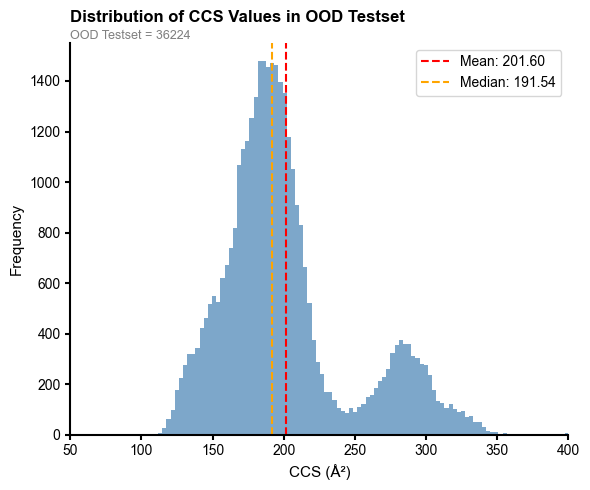

In [22]:
# Figure 1: Histogram of CCS distribution
fig, ax = plt.subplots(figsize=(6, 5)) 

ax.hist(df['ccs'], bins='auto', alpha=0.7, color='steelblue')
ax.set_xlabel('CCS (\u00c5\u00b2)')
ax.set_xlim(50, 400)
ax.set_ylabel('Frequency')

ax.set_title('Distribution of CCS Values in OOD Testset',fontweight='bold', loc='left', pad=15)                                                                                                                                                                                                  
ax.text(0, 1.01, f'OOD Testset = {df.shape[0]}',                                                                             
        transform=ax.transAxes, fontsize=9, color='gray')                                                                               

# Add summary statistics
mean_ccs = df['ccs'].mean()
median_ccs = df['ccs'].median()
ax.axvline(mean_ccs, color='red', linestyle='--', label=f'Mean: {mean_ccs:.2f}')
ax.axvline(median_ccs, color='orange', linestyle='--', label=f'Median: {median_ccs:.2f}')
ax.legend()

plt.tight_layout()
plt.show()

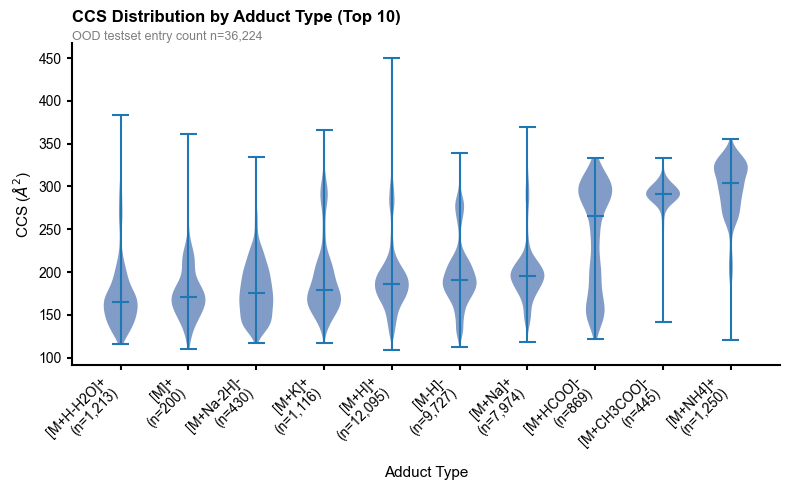

In [21]:
# Figure 2: Violin plot of CCS grouped by adduct (top 10)

# Top adducts by frequency
top_adducts = df['adduct'].value_counts().head(10).index.tolist()
df_top_adducts = df[df['adduct'].isin(top_adducts)].copy()

n = len(df)

fig, ax = plt.subplots(figsize=(8, 5))

# Order by median CCS
order = df_top_adducts.groupby('adduct')['ccs'].median().sort_values().index

parts = ax.violinplot(
    [df_top_adducts[df_top_adducts['adduct'] == a]['ccs'].values for a in order],
    positions=range(len(order)),
    showmeans=False,
    showmedians=True
)

# Color the violins
for pc in parts['bodies']:
    pc.set_facecolor('#4C72B0')
    pc.set_alpha(0.7)

# Add counts as labels
counts = [len(df_top_adducts[df_top_adducts['adduct'] == a]) for a in order]
labels = [f"{a}\n(n={c:,})" for a, c in zip(order, counts)]

ax.set_xticks(range(len(order)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel(r'CCS ($\AA^2$)')
ax.set_xlabel('Adduct Type')

ax.set_title('CCS Distribution by Adduct Type (Top 10)', loc='left', fontweight='bold', pad=15)
ax.text(0, 1.01, f'OOD testset entry count n={n:,}',
        transform=ax.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.show()